# 🤖 REINFORCE con baseline: robots que aprenden a caminar

Este cuaderno entrena un agente **REINFORCE con baseline** (gradiente de política + red de valor como línea base) sobre entornos de control continuo de Gymnasium.

- La política es una **gaussiana**: la red da la media de cada acción y hay una desviación estándar aprendible, así que maneja acciones continuas sin problema.
- Se graba un video **antes de entrenar** (el robot toma acciones aleatorias) y luego cada cierto número de iteraciones, para ver la evolución.
- Cambiar de robot en la celda de configuración: `BipedalWalker`, `HalfCheetah`, `Hopper`, `Walker2d`.

**Runtime recomendado: CPU (sin GPU).** La red es pequeña y el cuello de botella es el simulador, que corre en CPU. Una T4 no acelera esto (incluso puede ir más lento por las transferencias).

Flujo: ejecuta las celdas en orden. La celda de entrenamiento se puede volver a ejecutar para **seguir entrenando** donde se quedó.

## 1. Instalación

In [ ]:
!apt-get -qq update
!apt-get -qq install -y swig libgl1 libegl1 libglew-dev libosmesa6 libosmesa6-dev libglfw3 patchelf | tail -n 5
!pip -q install "gymnasium[box2d,mujoco]" imageio imageio-ffmpeg

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)


## 2. Configuración (aquí elegir el robot)

In [ ]:
#@title Configuración { display-mode: "form" }
ENV_ID = "Walker2d-v5" #@param ["BipedalWalker-v3", "HalfCheetah-v5", "Hopper-v5", "Walker2d-v5"]

N_ITERS      = 400   #@param {type:"integer"}
BATCH_STEPS  = 5000  #@param {type:"integer"}
VIDEO_EVERY  = 25    #@param {type:"integer"}
LR_POLICY    = 3e-4  #@param {type:"number"}
LR_VALUE     = 1e-3  #@param {type:"number"}
GAMMA        = 0.99  #@param {type:"number"}
ENT_COEF     = 0.0   #@param {type:"number"}
HIDDEN       = 128   #@param {type:"integer"}
SEED         = 0     #@param {type:"integer"}
VIDEO_STEPS  = 500   #@param {type:"integer"}

## 3. Código: normalizador, agente y entrenador

In [ ]:
import os, sys, subprocess

def _prueba_backend(gl):
    # Prueba en un subproceso (para no contaminar este kernel) si MuJoCo puede renderizar con ese backend.
    env = dict(os.environ, MUJOCO_GL=gl, PYOPENGL_PLATFORM=gl)
    prog = ("import gymnasium as gym; e=gym.make('HalfCheetah-v5', render_mode='rgb_array'); "
            "e.reset(seed=0); print(e.render().shape)")
    r = subprocess.run([sys.executable, "-c", prog], env=env, capture_output=True, text=True)
    return r.returncode == 0, r.stderr.strip().splitlines()[-1:]

if "BipedalWalker" not in ENV_ID:      # Box2D usa pygame y no necesita OpenGL
    orden = ["egl", "osmesa"] if os.path.exists("/dev/nvidia0") else ["osmesa", "egl"]
    for gl in orden:
        ok, err = _prueba_backend(gl)
        print(f"backend {gl}: {'OK' if ok else 'falla ' + str(err)}")
        if ok:
            os.environ["MUJOCO_GL"] = gl; os.environ["PYOPENGL_PLATFORM"] = gl
            break
    else:
        raise RuntimeError("Ningún backend de render funcionó. Ejecuta de nuevo la celda de instalación "
                           "(mira si apt dio errores) y reinicia la sesión.")

import time, base64
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import gymnasium as gym
import imageio
import matplotlib.pyplot as plt
from IPython.display import HTML, display

torch.set_num_threads(2)
os.makedirs("videos", exist_ok=True)
MIN_LOG_STD = -2.0


class RunningNorm:
    # Normaliza observaciones con media/varianza móviles (ayuda MUCHO a REINFORCE).
    def __init__(self, dim):
        self.mean = np.zeros(dim); self.var = np.ones(dim); self.count = 1e-4
    def update(self, x):
        bm, bv, bc = x.mean(0), x.var(0), x.shape[0]
        d = bm - self.mean; tot = self.count + bc
        self.mean = self.mean + d * bc / tot
        self.var = (self.var * self.count + bv * bc + d**2 * self.count * bc / tot) / tot
        self.count = tot
    def __call__(self, x):
        return np.clip((x - self.mean) / np.sqrt(self.var + 1e-8), -10, 10).astype(np.float32)


class Agent(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden=128, init_log_std=-0.5):
        super().__init__()
        self.mu = nn.Sequential(nn.Linear(obs_dim, hidden), nn.Tanh(),
                                nn.Linear(hidden, hidden), nn.Tanh(),
                                nn.Linear(hidden, act_dim))
        self.v = nn.Sequential(nn.Linear(obs_dim, hidden), nn.Tanh(),
                               nn.Linear(hidden, hidden), nn.Tanh(),
                               nn.Linear(hidden, 1))
        self.log_std = nn.Parameter(torch.full((act_dim,), float(init_log_std)))
        with torch.no_grad():               # empieza casi quieto: la exploración viene de la std
            self.mu[-1].weight.mul_(0.01); self.mu[-1].bias.zero_()
    def std(self):
        return self.log_std.clamp(MIN_LOG_STD, 1.0).exp()
    def dist(self, obs):
        return torch.distributions.Normal(self.mu(obs), self.std())
    def policy_params(self):
        return list(self.mu.parameters()) + [self.log_std]


class Trainer:
    def __init__(self, env_id, hidden, gamma, lr_pi, lr_v, ent_coef, batch_steps, seed, v_epochs=5):
        torch.manual_seed(seed)
        self.rng = np.random.default_rng(seed)
        self.env_id, self.gamma, self.ent_coef = env_id, gamma, ent_coef
        self.batch_steps, self.v_epochs = batch_steps, v_epochs
        self.env = gym.make(env_id)
        self.env.reset(seed=seed)
        self.low, self.high = self.env.action_space.low, self.env.action_space.high
        obs_dim = self.env.observation_space.shape[0]
        act_dim = self.env.action_space.shape[0]
        self.norm = RunningNorm(obs_dim)
        self.agent = Agent(obs_dim, act_dim, hidden)
        self.opt_pi = torch.optim.Adam(self.agent.policy_params(), lr=lr_pi)
        self.opt_v = torch.optim.Adam(self.agent.v.parameters(), lr=lr_v)
        self.ret_scale = None
        self.it = 0
        self.hist = {"it": [], "ret": [], "len": [], "std": []}
        self.videos = []          # (iteración, retorno medio, ruta)
        print(f"{env_id}: obs={obs_dim}, acciones={act_dim}, rango=[{self.low.min()}, {self.high.max()}]")

    def act(self, x, stochastic=True):
        with torch.no_grad():
            mu = self.agent.mu(torch.as_tensor(x)).numpy()
            if not stochastic:
                return mu
            std = self.agent.std().numpy()
        return mu + std * self.rng.standard_normal(mu.shape)

    def collect(self):
        O, A, G, raw, rets, lens = [], [], [], [], [], []
        steps = 0
        while steps < self.batch_steps:
            o, _ = self.env.reset()
            eo, ea, er, done = [], [], [], False
            while not done:
                raw.append(o)
                x = self.norm(o)
                a = self.act(x)
                o, r, term, trunc, _ = self.env.step(np.clip(a, self.low, self.high))
                eo.append(x); ea.append(a); er.append(r)
                done = term or trunc
            g, run = np.zeros(len(er), dtype=np.float32), 0.0
            for t in reversed(range(len(er))):       # retorno futuro descontado
                run = er[t] + self.gamma * run
                g[t] = run
            O += eo; A += ea; G.append(g)
            rets.append(sum(er)); lens.append(len(er)); steps += len(er)
        self.norm.update(np.array(raw))
        t = lambda z: torch.as_tensor(np.array(z), dtype=torch.float32)
        return t(O), t(A), torch.as_tensor(np.concatenate(G)), rets, lens

    def update(self, obs, act, G):
        s = G.std().item() + 1e-8
        self.ret_scale = s if self.ret_scale is None else 0.9 * self.ret_scale + 0.1 * s
        target = G / self.ret_scale                    # retornos en escala ~1
        with torch.no_grad():
            adv = target - self.agent.v(obs).squeeze(-1)   # ventaja = retorno - baseline
            adv = (adv - adv.mean()) / (adv.std() + 1e-8)
        dist = self.agent.dist(obs)
        logp = dist.log_prob(act).sum(-1)
        loss_pi = -(logp * adv).mean() - self.ent_coef * dist.entropy().sum(-1).mean()
        self.opt_pi.zero_grad(); loss_pi.backward()
        nn.utils.clip_grad_norm_(self.agent.policy_params(), 1.0)
        self.opt_pi.step()
        for _ in range(self.v_epochs):                 # el baseline se ajusta con varias pasadas
            loss_v = F.mse_loss(self.agent.v(obs).squeeze(-1), target)
            self.opt_v.zero_grad(); loss_v.backward(); self.opt_v.step()

    def record(self, label="", stochastic=True, max_steps=500):
        env = gym.make(self.env_id, render_mode="rgb_array")
        o, _ = env.reset(seed=int(self.rng.integers(10**9)))
        frames, total = [], 0.0
        for _ in range(max_steps):
            frames.append(env.render())
            a = self.act(self.norm(o), stochastic)
            o, r, term, trunc, _ = env.step(np.clip(a, self.low, self.high))
            total += r
            if term or trunc: break
        fps = env.metadata.get("render_fps", 30)
        env.close()
        path = f"videos/{self.env_id}_it{self.it:04d}{label}.mp4"
        imageio.mimsave(path, frames, fps=fps, macro_block_size=2)
        return path, total

    def train(self, n_iters, video_every=25, video_steps=500):
        if self.it == 0:
            self._video(video_steps, "🥚 inicio (iteración 0)")
        try:
            for _ in range(n_iters):
                t0 = time.time()
                self.it += 1
                obs, act, G, rets, lens = self.collect()
                self.update(obs, act, G)
                self.hist["it"].append(self.it); self.hist["ret"].append(np.mean(rets))
                self.hist["len"].append(np.mean(lens)); self.hist["std"].append(self.agent.std().mean().item())
                if self.it % 5 == 0 or self.it == 1:
                    print(f"it {self.it:4d} | retorno {np.mean(rets):8.1f} | largo ep {np.mean(lens):7.0f} "
                          f"| std acción {self.hist['std'][-1]:.2f} | {time.time()-t0:.1f}s")
                if self.it % video_every == 0:
                    self._video(video_steps, f"iteración {self.it}")
        except KeyboardInterrupt:
            print("⏹ Entrenamiento interrumpido (el estado se conserva, puedes continuar).")

    def _video(self, video_steps, caption):
        path, total = self.record(max_steps=video_steps)
        self.videos.append((self.it, total, path))
        show_videos([(f"{caption} — retorno {total:.0f}", path)])


def show_videos(items, width=380):
    html = '<div style="display:flex;flex-wrap:wrap;gap:8px">'
    for cap, path in items:
        b64 = base64.b64encode(open(path, "rb").read()).decode()
        html += (f'<div><div style="font:14px sans-serif;margin:2px">{cap}</div>'
                 f'<video width="{width}" controls loop muted autoplay '
                 f'src="data:video/mp4;base64,{b64}"></video></div>')
    display(HTML(html + "</div>"))


def plot_progress(tr, smooth=10):
    h = tr.hist
    if not h["it"]:
        print("Aún no hay datos."); return
    fig, ax = plt.subplots(1, 3, figsize=(15, 3.5))
    def sm(x):
        x = np.array(x); k = min(smooth, len(x))
        return np.convolve(x, np.ones(k) / k, mode="valid")
    ax[0].plot(h["it"], h["ret"], alpha=0.3)
    ax[0].plot(h["it"][len(h["it"]) - len(sm(h["ret"])):], sm(h["ret"])); ax[0].set_title("Retorno medio por iteración")
    ax[1].plot(h["it"], h["len"]); ax[1].set_title("Duración media del episodio")
    ax[2].plot(h["it"], h["std"]); ax[2].set_title("Desv. estándar de la acción (exploración)")
    for a in ax: a.set_xlabel("iteración"); a.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

backend osmesa: OK


## 4. Crear el agente
Se graba el video de la iteración 0 al empezar a entrenar. Volver a ejecutar esta celda reinicia todo desde cero.

In [ ]:
trainer = Trainer(ENV_ID, HIDDEN, GAMMA, LR_POLICY, LR_VALUE, ENT_COEF, BATCH_STEPS, SEED)

Walker2d-v5: obs=17, acciones=6, rango=[-1.0, 1.0]


## 5. Entrenar
Cada iteración recoge `BATCH_STEPS` pasos, hace **un** paso de gradiente de política y varios del baseline. Se puede interrumpir con el botón ⏹ y volver a ejecutar para continuar.

In [ ]:
trainer.train(N_ITERS, video_every=VIDEO_EVERY, video_steps=VIDEO_STEPS)

it    1 | retorno      2.3 | largo ep      22 | std acción 0.61 | 11.2s
it    5 | retorno      3.0 | largo ep      22 | std acción 0.61 | 3.4s
it   10 | retorno      4.1 | largo ep      24 | std acción 0.61 | 3.2s
it   15 | retorno      7.6 | largo ep      28 | std acción 0.60 | 3.4s
it   20 | retorno     12.1 | largo ep      31 | std acción 0.60 | 5.1s
it   25 | retorno     18.6 | largo ep      41 | std acción 0.60 | 3.5s


it   30 | retorno     45.2 | largo ep      60 | std acción 0.60 | 3.5s
it   35 | retorno    123.4 | largo ep     117 | std acción 0.60 | 6.3s
it   40 | retorno    230.6 | largo ep     169 | std acción 0.60 | 3.7s
it   45 | retorno    281.6 | largo ep     203 | std acción 0.60 | 3.7s
it   50 | retorno    278.5 | largo ep     194 | std acción 0.60 | 6.3s


it   55 | retorno    275.1 | largo ep     200 | std acción 0.60 | 3.8s
it   60 | retorno    251.0 | largo ep     184 | std acción 0.60 | 3.6s
it   65 | retorno    250.6 | largo ep     170 | std acción 0.60 | 6.5s
it   70 | retorno    273.0 | largo ep     181 | std acción 0.60 | 6.4s
it   75 | retorno    263.1 | largo ep     167 | std acción 0.60 | 3.8s


it   80 | retorno    241.4 | largo ep     161 | std acción 0.60 | 3.8s
it   85 | retorno    269.9 | largo ep     180 | std acción 0.60 | 6.3s
it   90 | retorno    278.3 | largo ep     182 | std acción 0.60 | 3.6s
it   95 | retorno    272.6 | largo ep     168 | std acción 0.60 | 3.6s
it  100 | retorno    278.1 | largo ep     168 | std acción 0.60 | 6.4s


it  105 | retorno    290.0 | largo ep     186 | std acción 0.60 | 3.7s
it  110 | retorno    292.8 | largo ep     187 | std acción 0.60 | 3.7s
it  115 | retorno    296.2 | largo ep     186 | std acción 0.60 | 6.5s
it  120 | retorno    296.9 | largo ep     184 | std acción 0.60 | 3.8s
it  125 | retorno    293.7 | largo ep     189 | std acción 0.60 | 3.8s


...

it  280 | retorno    457.6 | largo ep     220 | std acción 0.59 | 6.3s
it  285 | retorno    478.3 | largo ep     216 | std acción 0.59 | 3.6s
it  290 | retorno    478.7 | largo ep     220 | std acción 0.59 | 3.5s
it  295 | retorno    502.5 | largo ep     225 | std acción 0.59 | 6.3s
it  300 | retorno    525.9 | largo ep     233 | std acción 0.59 | 3.8s


it  305 | retorno    539.2 | largo ep     229 | std acción 0.59 | 3.5s
it  310 | retorno    565.2 | largo ep     263 | std acción 0.59 | 3.6s
it  315 | retorno    595.8 | largo ep     270 | std acción 0.59 | 4.4s
it  320 | retorno    586.9 | largo ep     266 | std acción 0.59 | 3.4s
it  325 | retorno    590.6 | largo ep     257 | std acción 0.59 | 6.4s


it  330 | retorno    590.1 | largo ep     276 | std acción 0.59 | 3.6s
it  335 | retorno    552.4 | largo ep     232 | std acción 0.59 | 5.8s
it  340 | retorno    587.7 | largo ep     264 | std acción 0.59 | 3.7s
it  345 | retorno    585.1 | largo ep     261 | std acción 0.59 | 6.5s
it  350 | retorno    673.8 | largo ep     283 | std acción 0.59 | 3.8s


it  355 | retorno    559.6 | largo ep     239 | std acción 0.59 | 3.5s
it  360 | retorno    619.8 | largo ep     260 | std acción 0.59 | 6.5s
it  365 | retorno    584.1 | largo ep     244 | std acción 0.59 | 6.6s
it  370 | retorno    558.6 | largo ep     232 | std acción 0.59 | 3.6s
it  375 | retorno    565.7 | largo ep     239 | std acción 0.59 | 4.0s


it  380 | retorno    631.7 | largo ep     267 | std acción 0.59 | 3.6s
it  385 | retorno    655.4 | largo ep     263 | std acción 0.59 | 6.4s
it  390 | retorno    772.1 | largo ep     320 | std acción 0.59 | 3.5s
it  395 | retorno    774.0 | largo ep     310 | std acción 0.59 | 5.5s
it  400 | retorno    715.2 | largo ep     290 | std acción 0.59 | 4.1s


## 6. Curvas de aprendizaje

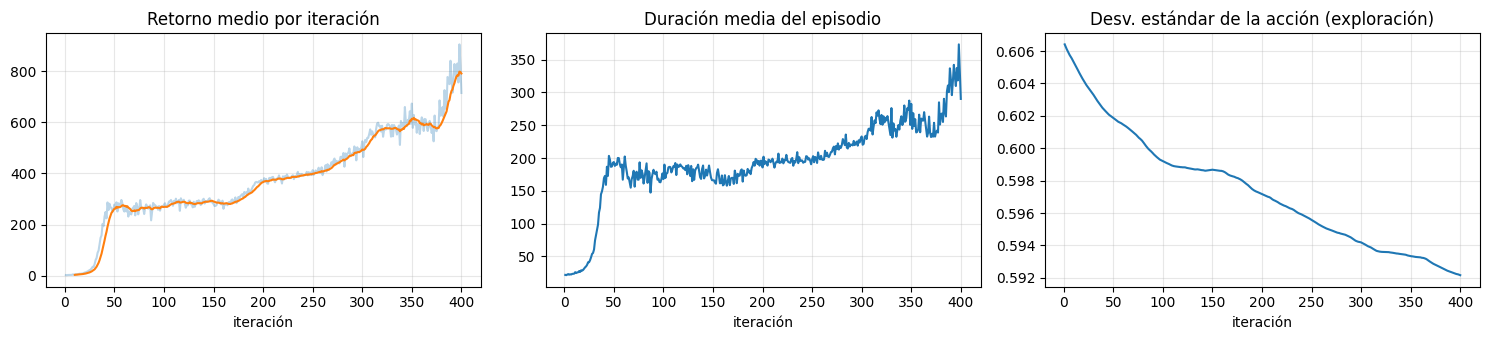

In [ ]:
plot_progress(trainer)

## 7. Galería de la evolución 🎞️
Los videos guardados en orden: del robot inicial al entrenado.

In [ ]:
MAX_VIDEOS = 8
vids = trainer.videos
idx = np.unique(np.linspace(0, len(vids) - 1, min(MAX_VIDEOS, len(vids))).astype(int))
show_videos([(f"it {vids[i][0]} — retorno {vids[i][1]:.0f}", vids[i][2]) for i in idx], width=300)

## 8. Ver al agente ahora mismo
`stochastic=True` muestra el comportamiento con ruido; `False` usa solo la media de la política.

In [ ]:
items = []
for stoch in (True, False):
    path, total = trainer.record(label="_stoch" if stoch else "_det", stochastic=stoch, max_steps=VIDEO_STEPS * 2)
    items.append((f"{'con ruido' if stoch else 'determinista'} — retorno {total:.0f}", path))
show_videos(items)

## 9. Guardar / cargar (opcional)

In [ ]:
torch.save({"agent": trainer.agent.state_dict(),
            "norm": (trainer.norm.mean, trainer.norm.var, trainer.norm.count)},
           f"{ENV_ID}_reinforce.pt")
# Para conservarlo entre sesiones: from google.colab import drive; drive.mount('/content/drive') y copia el .pt allí.

## Notas y consejos

- **Cambiar de robot:** modifica `ENV_ID` en la celda 2 y ejecuta desde la celda 4 (crear agente) hacia abajo. No hace falta reinstalar.
- **Qué esperar:** REINFORCE es de alta varianza y poco eficiente en muestras. En `HalfCheetah` verás que avanza (a veces de espaldas o volcado). `Hopper` suele aprender a dar saltos y luego a mantenerse en pie. `BipedalWalker` tarda más: lo normal es pasar por la fase de "quedarse quieto para no perder puntos" antes de caminar.
- **Si no mejora:** subir `BATCH_STEPS` (10000–20000) para reducir varianza, probar `ENT_COEF = 0.001`, o baja `LR_POLICY` a `1e-4`.
- **Si el render de MuJoCo falla** (error de `glGetError` / OpenGL): ejecuta de nuevo la celda de instalación, luego *Entorno de ejecución → Reiniciar sesión* y volver a ejecutar desde la celda 2. El backend de render debe fijarse antes de que OpenGL se importe por primera vez, por eso hay que reiniciar.
- **Bibliotecas:** Stable-Baselines3 no trae REINFORCE; trae A2C/PPO, que son el paso natural siguiente (A2C es básicamente REINFORCE con baseline aprendido y bootstrapping).